# Modelli Non Lineari per la Regressione


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

np.random.seed(667)

## 1. Creazione del Dataset Sintetico

Utilizziamo `make_regression` per creare un dataset con relazioni non lineari.

In [3]:
X, y = make_regression(
                        n_samples=1000,
                        n_features=10,
                        n_informative=8,
                        noise=50,
                        random_state=667,
                        )

# Aggiungiamo non linearità al dataset
y = y + 0.5 * X[:, 0]**2 + 0.3 * X[:, 1]**3

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=667,
                                                    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Range valori target: [{y.min():.2f}, {y.max():.2f}]")

Range valori target: [-685.05, 681.17]


## 2. Definizione dei Modelli Non Lineari

### 2.1 Decision Tree Regressor
**Funzionamento**: Gli alberi decisionali suddividono ricorsivamente lo spazio delle features in regioni, creando una struttura ad albero. Ogni foglia contiene una predizione (valore medio del target). Catturano naturalmente relazioni non lineari e interazioni tra features.

**Vantaggi**: Non richiede normalizzazione, interpreta interazioni complesse, visivamente interpretabile.

**Svantaggi**: Tende all'overfitting, instabile (piccole variazioni nei dati cambiano l'albero).

### 2.2 Random Forest Regressor
**Funzionamento**: Ensemble di alberi decisionali addestrati su campioni bootstrap del dataset. La predizione finale è la media delle predizioni di tutti gli alberi. Riduce la varianza rispetto a singoli alberi.

**Vantaggi**: Robusto all'overfitting, gestisce bene dati rumorosi, fornisce importanza delle features.

**Svantaggi**: Meno interpretabile, più lento in predizione.

### 2.3 Gradient Boosting Regressor
**Funzionamento**: Costruisce alberi sequenzialmente, dove ogni nuovo albero corregge gli errori del precedente. Utilizza il gradient descent nello spazio delle funzioni per minimizzare la loss.

**Vantaggi**: Spesso il migliore in termini di performance, molto flessibile.

**Svantaggi**: Può fare overfitting se non regolarizzato, richiede tuning attento degli iperparametri.

### 2.4 Support Vector Regressor (SVR)
**Funzionamento**: Cerca un iperpiano che meglio approssima i dati mantenendosi entro un margine di tolleranza (epsilon). Il kernel RBF (Radial Basis Function) permette di catturare relazioni non lineari mappando i dati in uno spazio a dimensione superiore.

**Vantaggi**: Efficace in spazi ad alta dimensionalità, robusto agli outlier.

**Svantaggi**: Richiede normalizzazione, computazionalmente costoso su grandi dataset.

In [ ]:
modelli = {
            'DecisionTree': DecisionTreeRegressor(
                                                    max_depth=10,
                                                    min_samples_split=20,
                                                    random_state=667,
                                                    ),
            'RandomForest': RandomForestRegressor(
                                                    n_estimators=100,
                                                    max_depth=15,
                                                    min_samples_split=10,
                                                    random_state=667,
                                                    n_jobs=-1,
                                                    ),
            'GradientBoosting': GradientBoostingRegressor(
                                                            n_estimators=80,
                                                            learning_rate=0.1,
                                                            max_depth=3,
                                                            random_state=667,
                                                            ),
            'SVR_supportVector_regressor': SVR(
                                                kernel='poly',#'rbf',
                                                C=100,
                                                gamma='scale',
                                                epsilon=0.3,
                                                ),
        }

print(f"Numero di modelli da valutare: {len(modelli)}")
print("Modelli:", list(modelli.keys()))

Numero di modelli da valutare: 4
Modelli: ['DecisionTree', 'RandomForest', 'GradientBoosting', 'SVR_supportVector_regressor']


## 3. Addestramento e Cross-Validazione

Eseguiamo la cross-validazione k-fold per ogni modello per ottenere una stima robusta delle performance.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

risultati = {}
print("="*70)
print("="*70)

for nome, modello in modelli.items():
    print(f"\n{'─'*70}")
    print(f"Modello: {nome}")
    print(f"{'─'*70}")

    # Per SVR usiamo i dati scalati
    if nome in ['SVR_supportVector_regressor']:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train
        X_test_model = X_test

    cv_scores = cross_val_score(
                                modello,
                                X_train_model,
                                y_train,
                                cv=cv,
                                scoring='r2',
                                n_jobs=-1,
                                )

    cv_mse = -cross_val_score(modello,
                              X_train_model,
                              y_train,
                              cv=cv,
                              scoring='neg_mean_squared_error',
                              n_jobs=-1,
                              )

    print(f"Cross-Validation R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Cross-Validation MSE: {cv_mse.mean():.2f} (+/- {cv_mse.std():.2f})")

    modello.fit(X_train_model, y_train)

    y_pred_train = modello.predict(X_train_model)
    y_pred_test = modello.predict(X_test_model)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)

    print(f"\nPerformance sul Test Set:")
    print(f"  R² Score: {r2_test:.4f}")
    print(f"  RMSE: {rmse_test:.2f}")
    print(f"  MAE: {mae_test:.2f}")
    print(f"  MSE: {mse_test:.2f}")
    print(f"\nR² Training Set: {r2_train:.4f}")
    print(f"Differenza R² (Train-Test): {(r2_train - r2_test):.4f}")

    if (r2_train - r2_test) > 0.1:
        print("Possibile overfitting")

    # Salvataggio risultati
    risultati[nome] = {
                        'modello': modello,
                        'y_pred_test': y_pred_test,
                        'y_pred_train': y_pred_train,
                        'cv_r2_mean': cv_scores.mean(),
                        'cv_r2_std': cv_scores.std(),
                        'r2_test': r2_test,
                        'r2_train': r2_train,
                        'rmse': rmse_test,
                        'mae': mae_test,
                        'mse': mse_test
                        }

print("\n" + "="*70)
print("ADDESTRAMENTO COMPLETATO")
print("="*70)


──────────────────────────────────────────────────────────────────────
Modello: DecisionTree
──────────────────────────────────────────────────────────────────────
Cross-Validation R² Score: 0.4991 (+/- 0.0595)
Cross-Validation MSE: 20089.82 (+/- 2937.10)

Performance sul Test Set:
  R² Score: 0.5162
  RMSE: 134.87
  MAE: 108.84
  MSE: 18188.58

R² Training Set: 0.8395
Differenza R² (Train-Test): 0.3233
Possibile overfitting

──────────────────────────────────────────────────────────────────────
Modello: RandomForest
──────────────────────────────────────────────────────────────────────
Cross-Validation R² Score: 0.4991 (+/- 0.0595)
Cross-Validation MSE: 20089.82 (+/- 2937.10)

Performance sul Test Set:
  R² Score: 0.5162
  RMSE: 134.87
  MAE: 108.84
  MSE: 18188.58

R² Training Set: 0.8395
Differenza R² (Train-Test): 0.3233
Possibile overfitting

──────────────────────────────────────────────────────────────────────
Modello: RandomForest
──────────────────────────────────────────────

## 4. Confronto delle Performance


RIEPILOGO PERFORMANCE DEI MODELLI
                    Modello  CV R² (mean)  CV R² (std)  Test R²  Train R²       RMSE        MAE
           GradientBoosting      0.844022     0.022310 0.848850  0.953214  75.385961  60.372270
               RandomForest      0.766970     0.020534 0.795706  0.938207  87.642302  68.822273
SVR_supportVector_regressor      0.733241     0.036018 0.739976  0.854055  98.876486  74.182750
               DecisionTree      0.499115     0.059505 0.516243  0.839511 134.865052 108.842988


C:\Users\danie\AppData\Local\Temp\ipykernel_23968\2829782020.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(confronto_df['Modello'], rotation=45, ha='right')


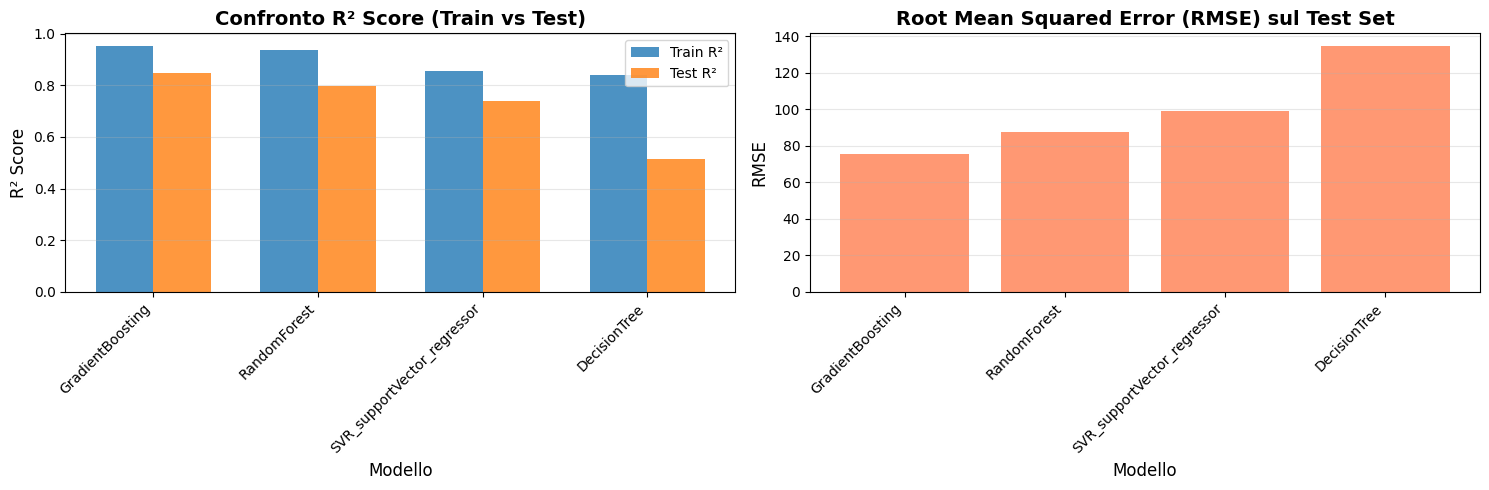

In [ ]:
confronto_df = pd.DataFrame({
                            'Modello': list(risultati.keys()),
                            'CV R² (mean)': [r['cv_r2_mean'] for r in risultati.values()],
                            'CV R² (std)': [r['cv_r2_std'] for r in risultati.values()],
                            'Test R²': [r['r2_test'] for r in risultati.values()],
                            'Train R²': [r['r2_train'] for r in risultati.values()],
                            'RMSE': [r['rmse'] for r in risultati.values()],
                            'MAE': [r['mae'] for r in risultati.values()]
                            })

# Ordinamento per R² sul test set
confronto_df = confronto_df.sort_values('Test R²', ascending=False)

print("\n" + "="*100)
print("RIEPILOGO PERFORMANCE DEI MODELLI")
print("="*100)
print(confronto_df.to_string(index=False))
print("="*100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(confronto_df))
width = 0.35

axes[0].bar(x - width/2, confronto_df['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, confronto_df['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].set_xlabel('Modello', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Confronto R² Score (Train vs Test)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(confronto_df['Modello'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(confronto_df['Modello'], confronto_df['RMSE'], alpha=0.8, color='coral')
axes[1].set_xlabel('Modello', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Root Mean Squared Error (RMSE) sul Test Set', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(confronto_df['Modello'], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analisi dei Residui per Ogni Modello

I residui (differenza tra valori reali e predetti) ci aiutano a capire:
- **Distribuzione**: I residui dovrebbero essere normalmente distribuiti attorno allo zero
- **Omoschedasticità**: La varianza dei residui dovrebbe essere costante
- **Pattern**: Non dovrebbero esserci pattern sistematici nei residui

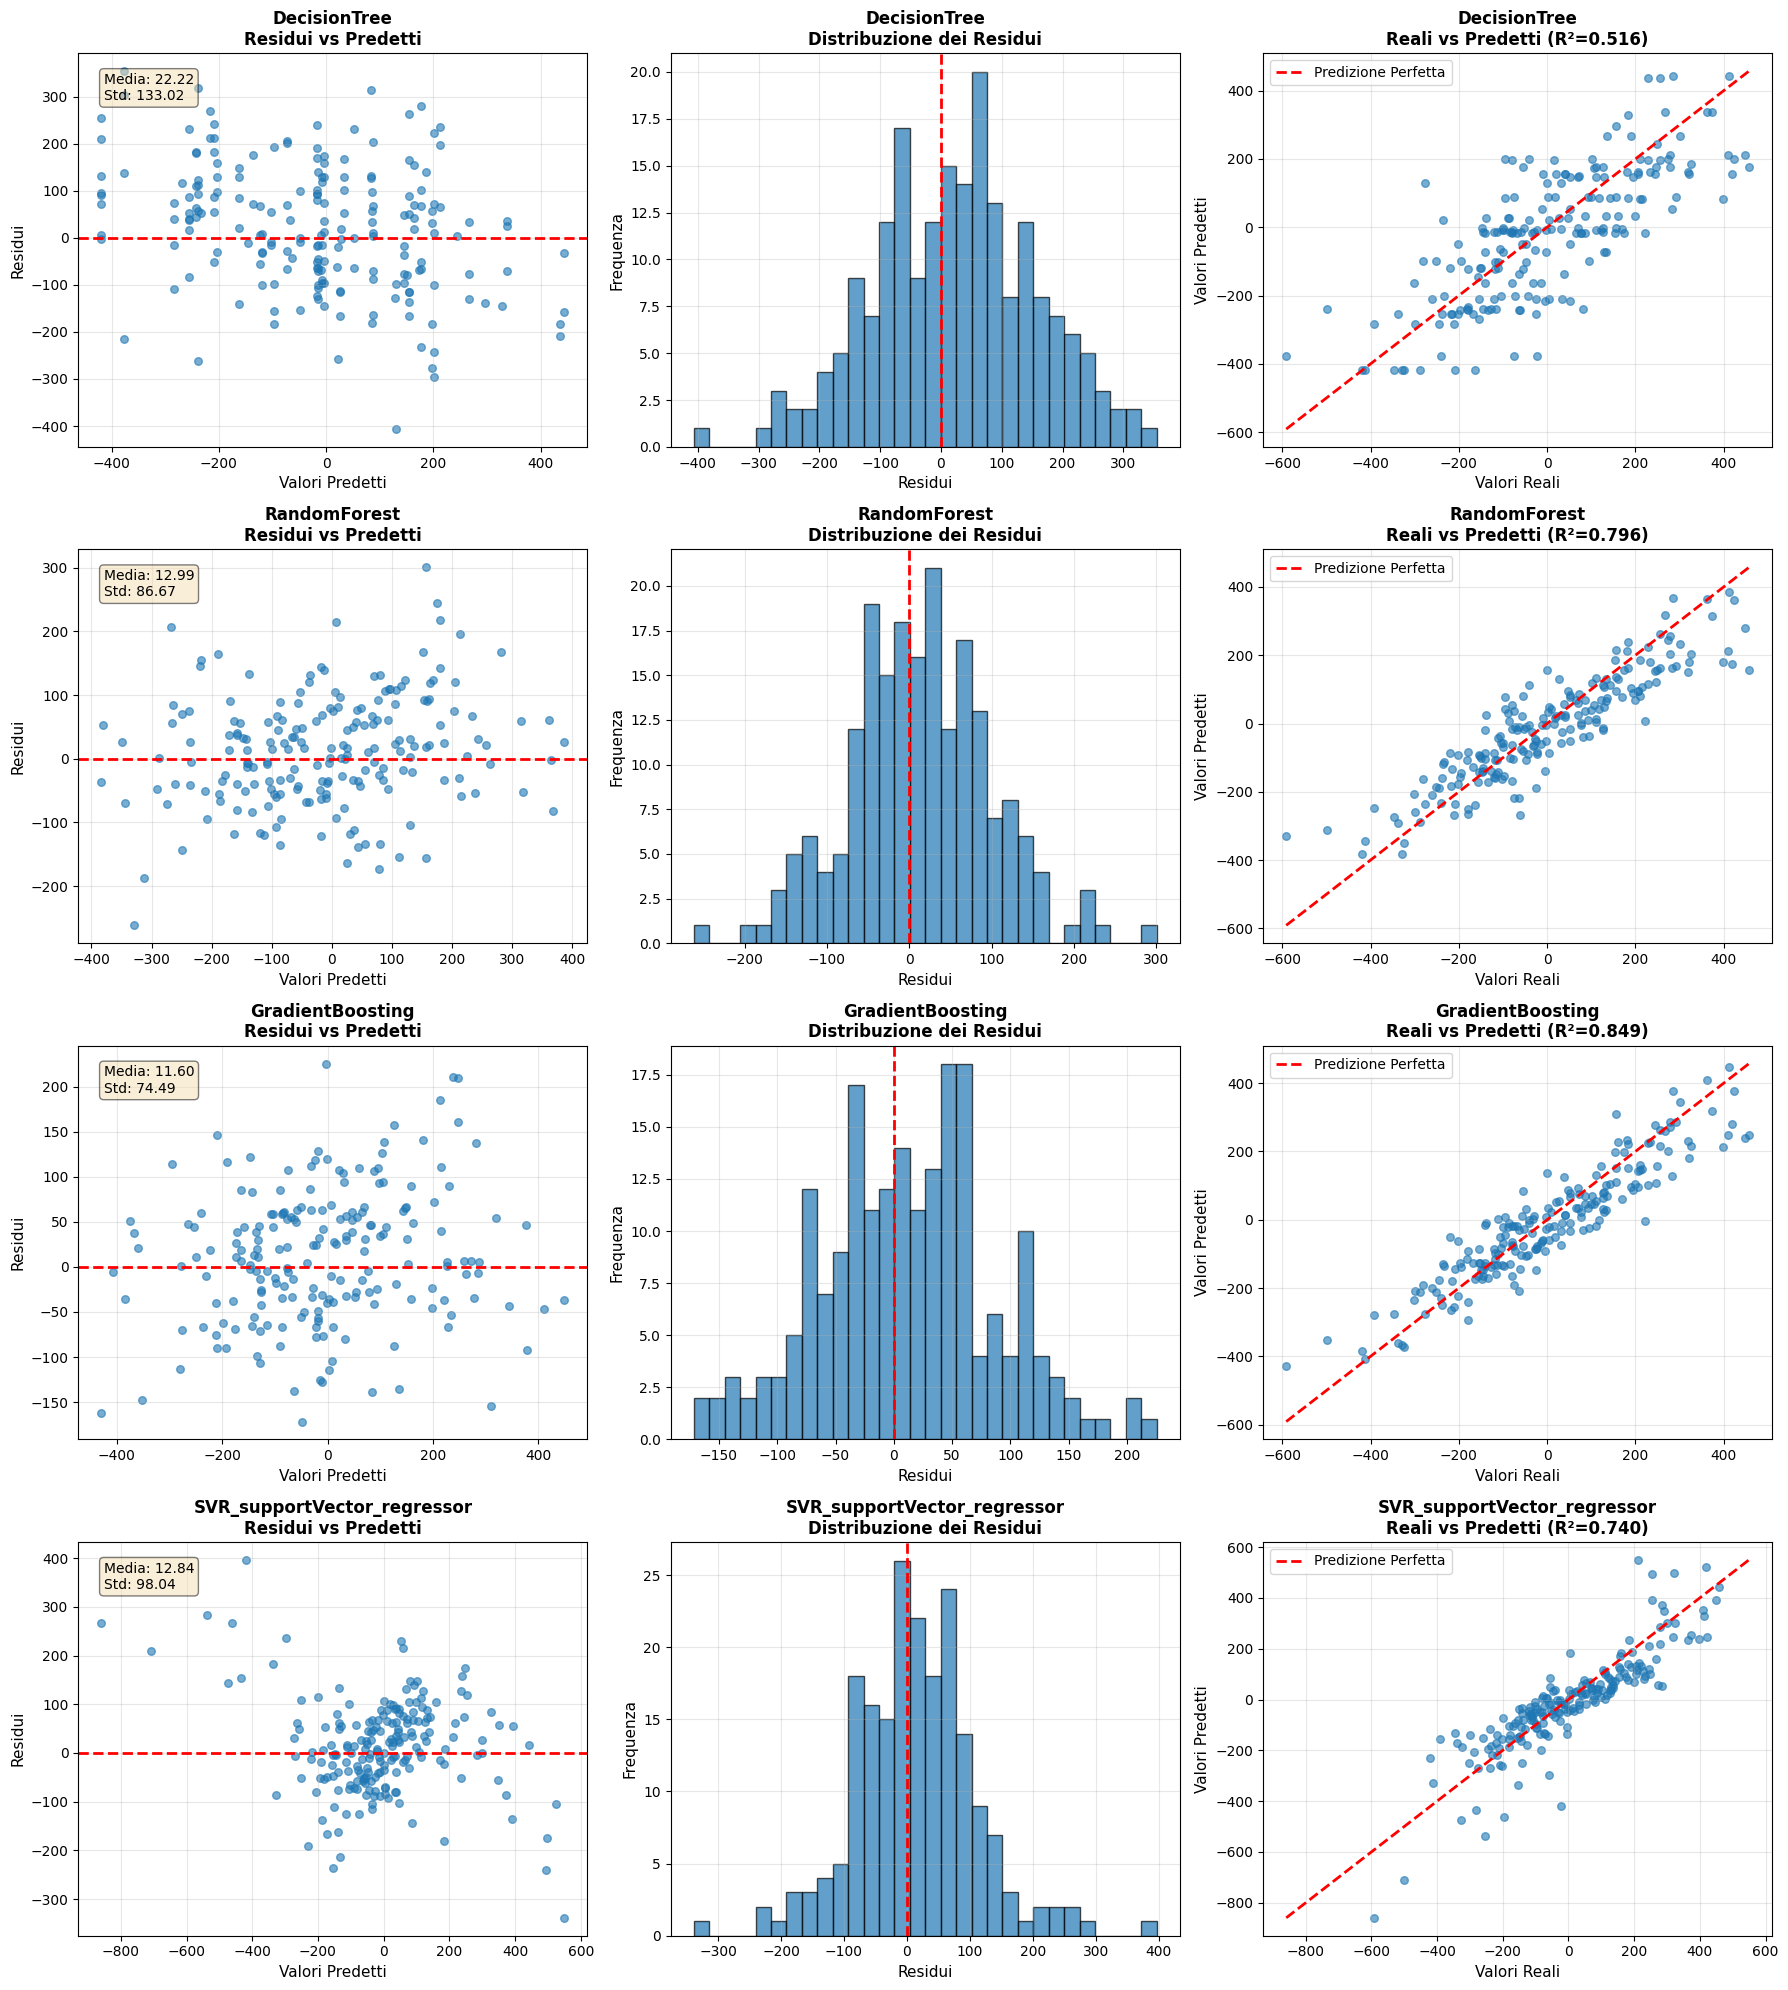


✓ Grafici dei residui salvati!


In [ ]:
n_modelli = len(risultati)
fig, axes = plt.subplots(n_modelli, 3, figsize=(18, 5*n_modelli))

if n_modelli == 1:
    axes = axes.reshape(1, -1)

for idx, (nome, risultato) in enumerate(risultati.items()):
    y_pred = risultato['y_pred_test']
    residui = y_test - y_pred

    # Plot 1: Residui vs Valori Predetti
    axes[idx, 0].scatter(y_pred, residui, alpha=0.6, s=30)
    axes[idx, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[idx, 0].set_xlabel('Valori Predetti', fontsize=11)
    axes[idx, 0].set_ylabel('Residui', fontsize=11)
    axes[idx, 0].set_title(f'{nome}\nResidui vs Predetti', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(alpha=0.3)

    # Aggiungi statistiche
    media_residui = np.mean(residui)
    std_residui = np.std(residui)
    axes[idx, 0].text(0.05, 0.95, f'Media: {media_residui:.2f}\nStd: {std_residui:.2f}',
                     transform=axes[idx, 0].transAxes,
                     verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 2: Distribuzione dei Residui
    axes[idx, 1].hist(residui, bins=30, edgecolor='black', alpha=0.7)
    axes[idx, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[idx, 1].set_xlabel('Residui', fontsize=11)
    axes[idx, 1].set_ylabel('Frequenza', fontsize=11)
    axes[idx, 1].set_title(f'{nome}\nDistribuzione dei Residui', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(alpha=0.3)

    # Plot 3: Valori Reali vs Predetti
    axes[idx, 2].scatter(y_test, y_pred, alpha=0.6, s=30)

    # Linea di perfetta predizione
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx, 2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predizione Perfetta')

    axes[idx, 2].set_xlabel('Valori Reali', fontsize=11)
    axes[idx, 2].set_ylabel('Valori Predetti', fontsize=11)
    axes[idx, 2].set_title(f'{nome}\nReali vs Predetti (R²={risultato["r2_test"]:.3f})',
                          fontsize=12, fontweight='bold')
    axes[idx, 2].legend()
    axes[idx, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analisi_residui_completa.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Grafici dei residui salvati!")

## 6. Q-Q Plot per Valutare la Normalità dei Residui

Il Q-Q plot confronta la distribuzione dei residui con una distribuzione normale teorica.

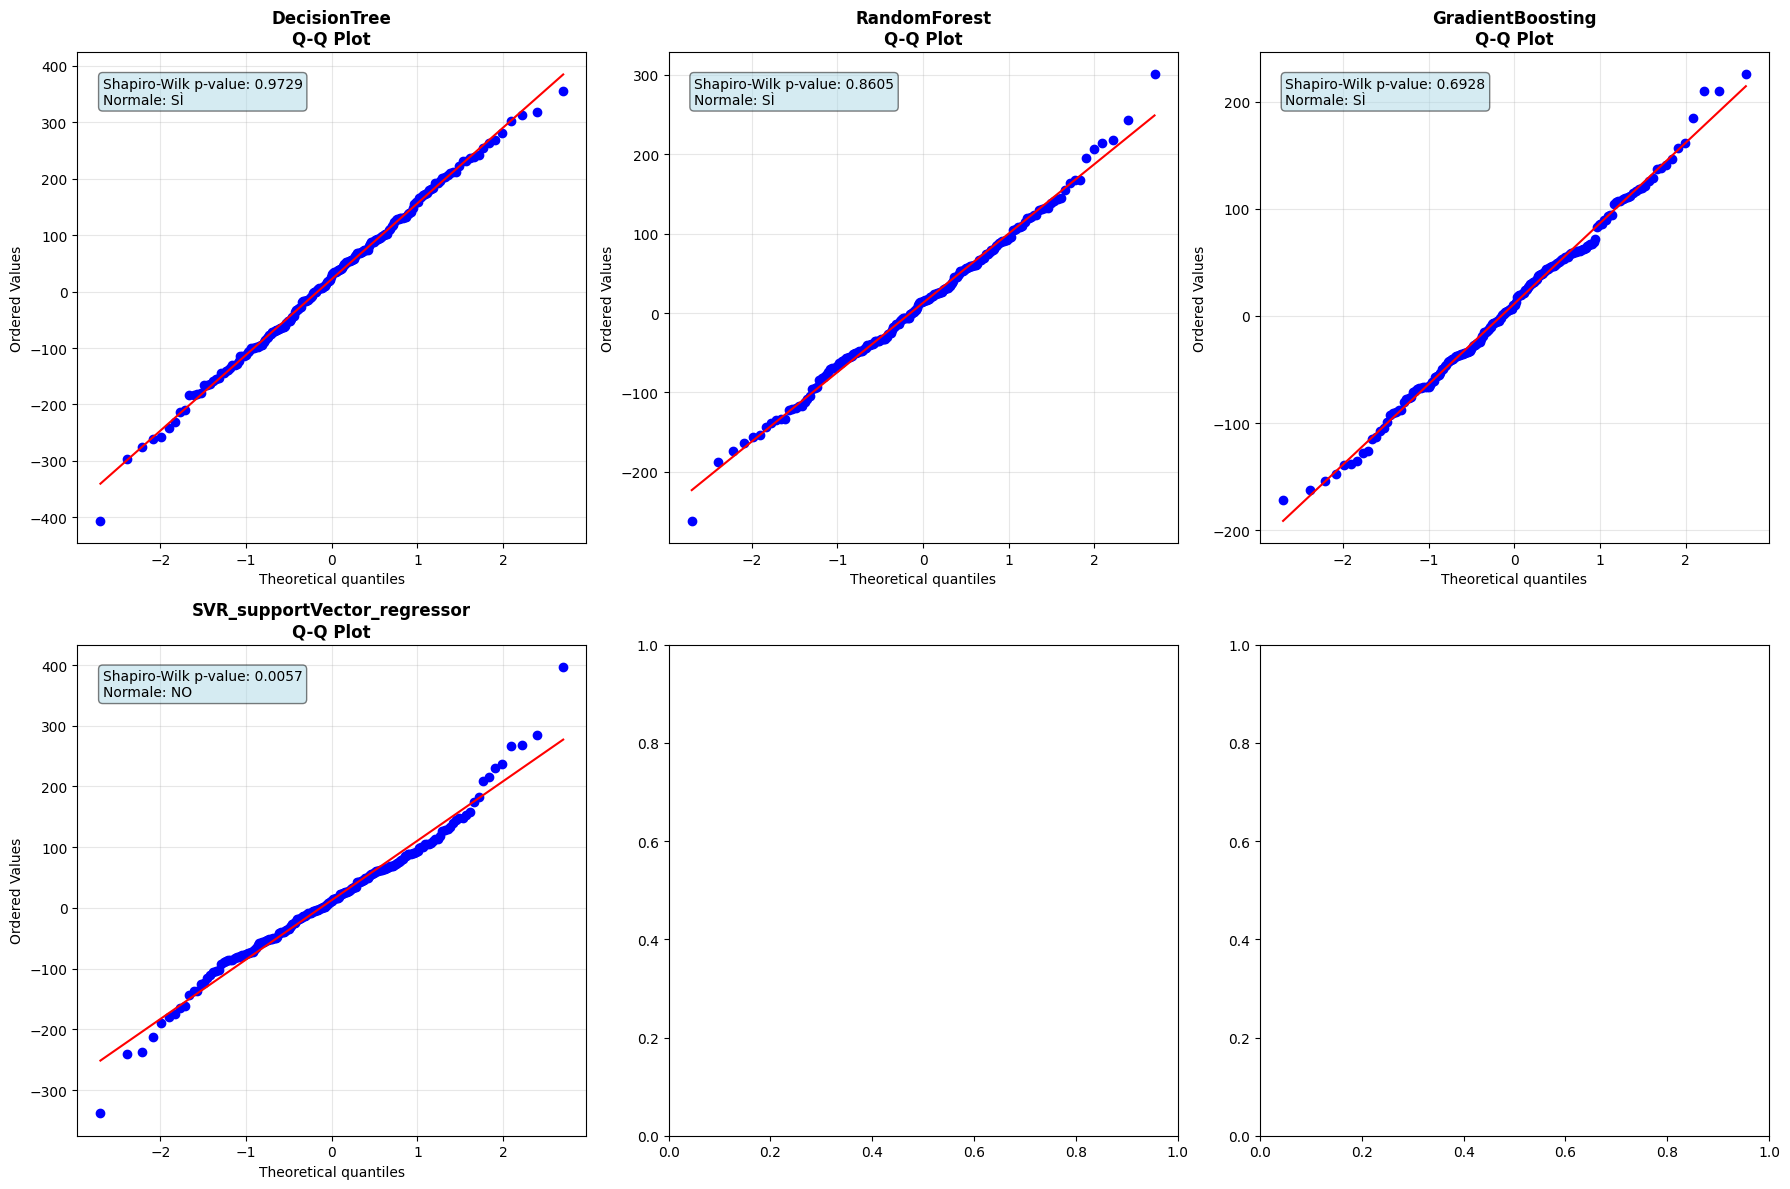


✓ Q-Q plots salvati!


In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (nome, risultato) in enumerate(risultati.items()):
    y_pred = risultato['y_pred_test']
    residui = y_test - y_pred

    # Q-Q plot
    stats.probplot(residui, dist="norm", plot=axes[idx])
    axes[idx].set_title(f'{nome}\nQ-Q Plot', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

    # Test di normalità (Shapiro-Wilk)
    statistic, p_value = stats.shapiro(residui)
    normalita = "SÌ" if p_value > 0.05 else "NO"
    axes[idx].text(0.05, 0.95, f'Shapiro-Wilk p-value: {p_value:.4f}\nNormale: {normalita}',
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Q-Q plots salvati!")

## 7. Conclusioni e Raccomandazioni

### Interpretazione dei Risultati

**Cosa cercare nei residui:**
1. **Residui centrati sullo zero**: Indica che il modello non è sistematicamente distorto
2. **Varianza costante**: I residui dovrebbero avere spread simile per tutti i valori predetti
3. **Distribuzione normale**: I residui dovrebbero seguire una distribuzione normale
4. **Assenza di pattern**: Pattern nei residui indicano che il modello non cattura alcune relazioni

**Scelta del modello migliore:**
- Confronta R² tra train e test per identificare overfitting
- Considera la cross-validation per robustezza
- Valuta il trade-off tra performance e interpretabilità
- Considera i requisiti computazionali

### Prossimi Passi
1. Ottimizzazione degli iperparametri (GridSearch, RandomSearch)
2. Feature engineering e selezione
3. Ensemble di modelli diversi
4. Validazione su nuovi dati

In [ ]:
migliore_modello = max(risultati.items(), key=lambda x: x[1]['r2_test'])

print("\n" + "="*70)
print("MODELLO MIGLIORE")
print("="*70)
print(f"\n🏆 {migliore_modello[0]}")
print(f"\nMetriche:")
print(f"  R² Test: {migliore_modello[1]['r2_test']:.4f}")
print(f"  R² Train: {migliore_modello[1]['r2_train']:.4f}")
print(f"  CV R² Mean: {migliore_modello[1]['cv_r2_mean']:.4f} (+/- {migliore_modello[1]['cv_r2_std']:.4f})")
print(f"  RMSE: {migliore_modello[1]['rmse']:.2f}")
print(f"  MAE: {migliore_modello[1]['mae']:.2f}")
print("\n" + "="*70)


MODELLO MIGLIORE

🏆 GradientBoosting

Metriche:
  R² Test: 0.8488
  R² Train: 0.9532
  CV R² Mean: 0.8440 (+/- 0.0223)
  RMSE: 75.39
  MAE: 60.37



In [ ]:
migliore_modello[0]

'GradientBoosting'

In [ ]:
from supertree import SuperTree

super_tree = SuperTree(modelli[migliore_modello[0]],X, y)
super_tree.show_tree()